In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("data/184 moviereviews.csv")

In [4]:
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


<Axes: xlabel='label'>

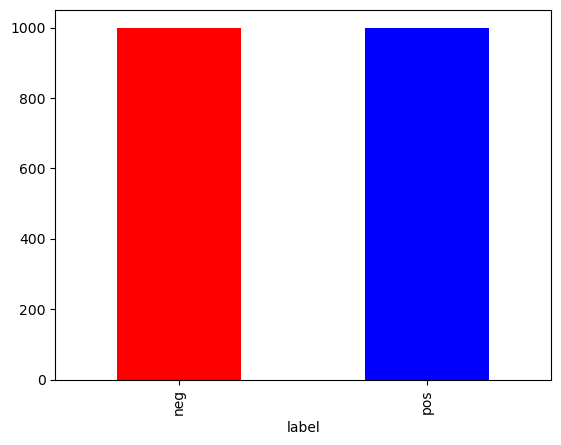

In [5]:
df["label"].value_counts().plot(kind="bar",color=["red","blue"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2000 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [7]:
df.isna().sum()

label      0
review    35
dtype: int64

In [8]:
df=df.dropna()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   1965 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 46.1+ KB


In [10]:
df["label"].nunique()

2

In [11]:
df["label"].str.isspace()

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Name: label, Length: 1965, dtype: bool

In [45]:
from sklearn.feature_extraction.text import CountVectorizer

cv1=CountVectorizer(stop_words="english")
cv2=CountVectorizer(stop_words="english")

In [46]:
pos_df=df[df["label"]=="pos"]
neg_df=df[df["label"]=="neg"]


In [48]:
cv1.fit(pos_df["review"])


,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [49]:
cv2.fit(neg_df["review"])

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [50]:
cv_pos_words=cv1.transform(pos_df["review"])
cv_neg_words=cv2.transform(pos_df["review"])

In [51]:
cv_pos_words,cv_neg_words

(<Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 247042 stored elements and shape (982, 29459)>,
 <Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 230879 stored elements and shape (982, 27473)>)

In [72]:
words_pos=cv1.vocabulary_
words_pos
words_neg=cv2.vocabulary_


In [62]:
words_neg

{'films': 9152,
 'like': 14210,
 'mouse': 15983,
 'hunt': 11855,
 'theatres': 24529,
 'isn': 12921,
 'law': 13916,
 'diabolical': 6683,
 'load': 14353,
 'claptrap': 4469,
 'steven': 23318,
 'speilberg': 22873,
 'dreamworks': 7397,
 'studio': 23583,
 'hollywood': 11543,
 'family': 8836,
 'fare': 8867,
 'deadly': 6124,
 'worst': 27168,
 'takes': 24183,
 'bare': 2144,
 'threads': 24630,
 'plot': 18292,
 'tries': 25188,
 'prop': 19010,
 'overacting': 17214,
 'flat': 9302,
 'stupid': 23615,
 'slapstick': 22308,
 'makes': 14793,
 'comedies': 4820,
 'jingle': 13137,
 'way': 26680,
 'look': 14450,
 'decent': 6182,
 'comparison': 4901,
 'writer': 27224,
 'adam': 675,
 'rifkin': 20530,
 'director': 6839,
 'gore': 10435,
 'verbinski': 26198,
 'names': 16206,
 'chiefly': 4258,
 'responsible': 20296,
 'swill': 24047,
 'worth': 27169,
 'concerns': 5018,
 'brothers': 3323,
 'nathan': 16249,
 'lane': 13816,
 'appalling': 1386,
 'lee': 14002,
 'evens': 8384,
 'inherit': 12478,
 'poorly': 18449,
 'run':

In [63]:
cv1.vocabulary_.items()

dict_items([('extraordinary', 9463), ('year', 29271), ('australian', 2005), ('films', 9941), ('shine', 23523), ('just', 14347), ('scooped', 22918), ('pool', 19799), ('film', 9925), ('institute', 13604), ('awards', 2087), ('picking', 19410), ('best', 2737), ('actor', 664), ('director', 7401), ('add', 696), ('gritty', 11530), ('life', 15231), ('anguish', 1341), ('courage', 5993), ('friendship', 10562), ('group', 11576), ('male', 15897), ('prisoners', 20225), ('hiv', 12399), ('positive', 19881), ('section', 23100), ('jail', 14007), ('love', 15596), ('catastrophes', 4207), ('low', 15618), ('budget', 3630), ('gem', 10903), ('straight', 25106), ('gay', 10865), ('near', 17517), ('university', 27639), ('campus', 3953), ('recall', 21122), ('rich', 22016), ('varied', 28026), ('celluloid', 4305), ('library', 15208), ('unleashed', 27653), ('australia', 2004), ('bookend', 3181), ('stand', 24807), ('dead', 6629), ('heart', 12090), ('opening', 18252), ('credits', 6131), ('theme', 26285), ('division',

In [73]:
top_20_pos=sorted(words_pos.items(),key =lambda x:x[1],reverse=True)[:20]
top_20_neg=sorted(words_neg.items(),key =lambda x:x[1],reverse=True)[:20]

In [74]:
top_20_pos

[('zycie', 29458),
 ('zwigoff', 29457),
 ('zwick', 29456),
 ('zweibel', 29455),
 ('zus', 29454),
 ('zurg', 29453),
 ('zundel', 29452),
 ('zukovsky', 29451),
 ('zuko', 29450),
 ('zuehlke', 29449),
 ('zucker', 29448),
 ('zorro', 29447),
 ('zorg', 29446),
 ('zophres', 29445),
 ('zooms', 29444),
 ('zooming', 29443),
 ('zoom', 29442),
 ('zoologist', 29441),
 ('zoolander', 29440),
 ('zookeepers', 29439)]

In [75]:
top_20_neg

[('zzzzzzz', 27472),
 ('zwigoff', 27471),
 ('zwick', 27470),
 ('zulu', 27469),
 ('zucker', 27468),
 ('zsigmond', 27467),
 ('zorro', 27466),
 ('zoot', 27465),
 ('zooms', 27464),
 ('zooming', 27463),
 ('zoom', 27462),
 ('zoologists', 27461),
 ('zoologist', 27460),
 ('zoo', 27459),
 ('zones', 27458),
 ('zone', 27457),
 ('zombified', 27456),
 ('zombies', 27455),
 ('zombie', 27454),
 ('zoe', 27453)]

In [79]:
df.columns

Index(['label', 'review'], dtype='object')

In [80]:
X=df["review"]
y=df["label"]

In [81]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=101)

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

pipe =Pipeline([("tfidf",TfidfVectorizer()),
               ("model",GradientBoostingClassifier())])


In [93]:
pipe.fit(X_train,y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [94]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [95]:
preds=pipe.predict(X_test)

In [96]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

         neg       0.78      0.80      0.79       188
         pos       0.81      0.80      0.80       205

    accuracy                           0.80       393
   macro avg       0.80      0.80      0.80       393
weighted avg       0.80      0.80      0.80       393



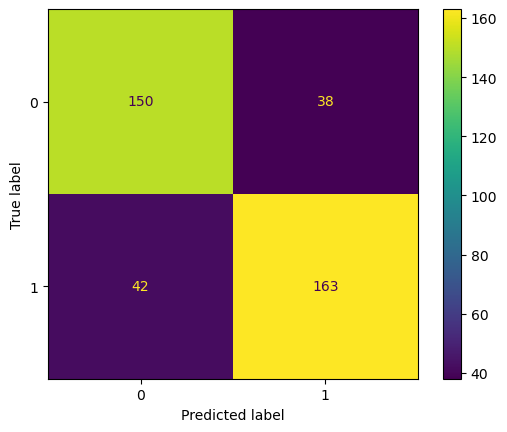

In [97]:
ConfusionMatrixDisplay(confusion_matrix(y_test,preds)).plot()